# Resumen para mí de las cosas que tenemos y qué puedo necesitar

## Lo que ya hay



-Diego ha dado resultados para:

1) Posición del primer pico de transmisión para una misma masa en cada barrera y pozo (Hizo esto para varias masas, pero en cada vez usó la misma). Doy por hecho que eran 2 barreras y 3 pozos porque no lo especifica y son los valores por defecto. También entiendo que el eje vertical es la energía y el horizontal la masa=> Sale una relación exponencial E vs m
2) Mueve por igual todos los potenciales y representa el valor de la primera enería de transmisión máxima que hay. Dice que hay 2 barreras y 3 pozos. El resultado de eso es una constante
3) Sinceramente no termino de entenderlo bien. Creo que dejando constantes las barreras y la anchura (y el numero de barreras siendo alto también constante??), va cambiando las masas efectivas y grafica el ancho de banda (no sé si se refiere a lo que mide la primera zona de tal). Luego lo de las "Familias" no sé a qué se refiere

-JR:

1) No lo ha puesto explícitamente PERO; viendo los resultados de los txt se ha puesto a graficar energía y ocurrencias que es el dibujo de las bandas (lo que pasaba para N grande)
2) Según sus resultados dice que lo que ve es que si la diferencia entre energías del pozo y la barrera cambian, desplazas en vertical las bandas. 
3) Cuando la diferencia de potencial es grande se aplanan las zonas de Brillouin (entiendo que es que la banda parece más recta)

Yo puedo entonces ver qué pasa para:

1) No ha hecho ninguno nada de ver lo que pasa si dejas la masa y energía constante y mueves la distancia entre barreras (Para pocas barreras puedo hacer como Diego y graficar el primer pico de transmisión)

2) Sobre modificar distancias compruebo lo mismo pero para muchos pozos

### Primera simulación para 2 barreras y 3 pozos: Pruebo a dejar mismas distancias en cada iteracion y las voy incrementando para graficar la energía del primer pico de transmisión (la masa efectiva se queda en 0,067 en cada region y las barreras y pozo son 4 y 0eV). Mecánica análoga a Diego: si el primero es 4-2-6-2-4 nm, el siguiente es 5-3-7-3-5nm...

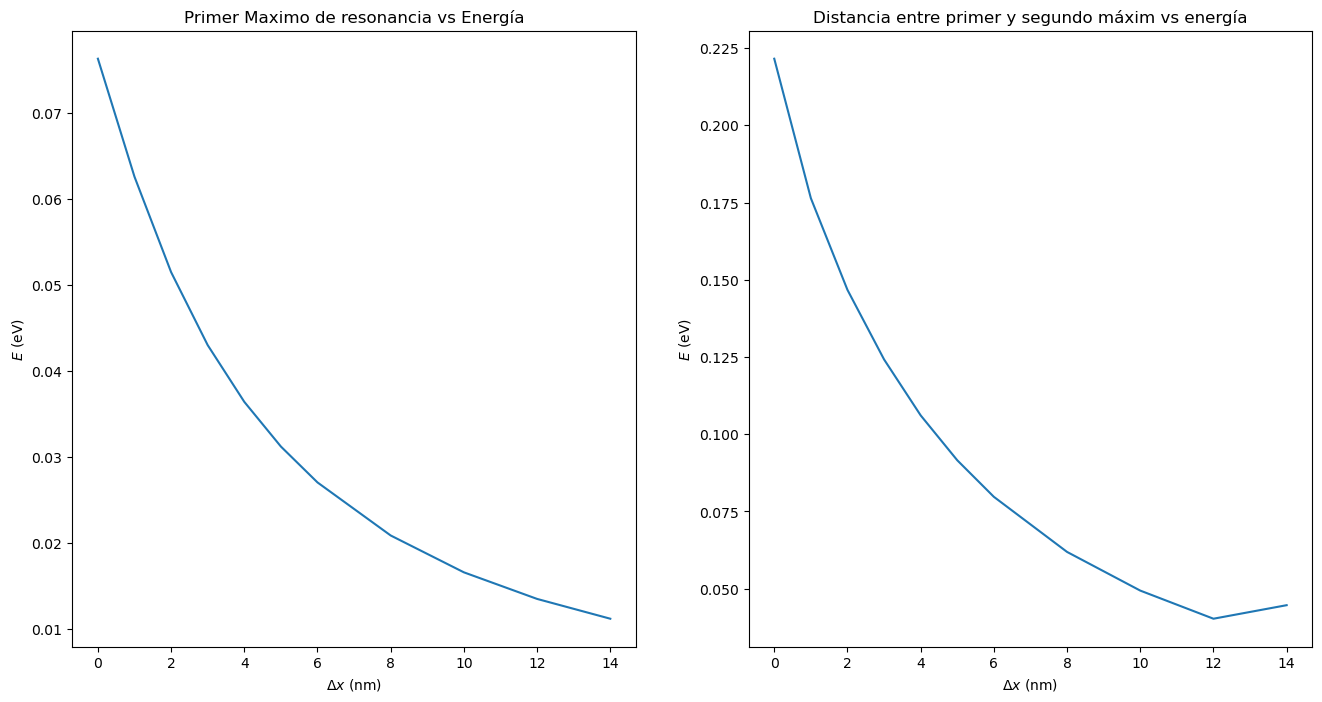

In [12]:
import numpy as np
import matplotlib.pyplot as plt

Data=np.loadtxt("Sim1.txt", skiprows=1)

x=Data[:, 0]
y1=Data[:, 1]
y2=Data[:,2]

fig, ax=plt.subplots(1,2, figsize=(16,8))

ax[0].plot(x,y1)
ax[0].set_title("Primer Maximo de resonancia vs Energía")
ax[0].set_xlabel(r'$\Delta x$ (nm)')
ax[0].set_ylabel(r'$E$ (eV)')

ax[1].plot(x, y2)
ax[1].set_title("Distancia entre primer y segundo máxim vs energía")
ax[1].set_ylabel(r'$E$ (eV)')
ax[1].set_xlabel(r'$\Delta x$ (nm)')

plt.show()


Viendo eso pensé que era una exponencial de calle, pero cuando la calculé salía un poco meh, al final probé la potencial con un desplazamiento C y salía clavado. Puse el ajuste de las dos formas aquí abajo

<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:45: SyntaxWarning: invalid escape sequence '\c'
<>:70: SyntaxWarning: invalid escape sequence '\c'
<>:84: SyntaxWarning: invalid escape sequence '\c'
<>:31: SyntaxWarning: invalid escape sequence '\c'
<>:45: SyntaxWarning: invalid escape sequence '\c'
<>:70: SyntaxWarning: invalid escape sequence '\c'
<>:84: SyntaxWarning: invalid escape sequence '\c'
/var/folders/m5/912tdpsj605ckbd78snkwfqr0000gn/T/ipykernel_4522/811796035.py:31: SyntaxWarning: invalid escape sequence '\c'
  ax[0].plot(x_fit, y_fit, '-', label=f'Ajuste: ${popt_exp[0]:.2f} \cdot e^{{{popt_exp[1]:.2f}x}}$', color='red')
/var/folders/m5/912tdpsj605ckbd78snkwfqr0000gn/T/ipykernel_4522/811796035.py:45: SyntaxWarning: invalid escape sequence '\c'
  ax[1].plot(x_fit, y_fit, '-', label=f'Ajuste: ${popt_pot[0]:.2f} \cdot (x+{popt_pot[2]})^{{{popt_pot[1]}}}$', color='red')
/var/folders/m5/912tdpsj605ckbd78snkwfqr0000gn/T/ipykernel_4522/811796035.py:70: SyntaxWarning: invalid

Ajuste Exponencial: A = 0.0732, B = -0.1612
Ajuste Exponencial: A = 15.9400, B = -2.2771
Ajuste Exponencial: A = 0.2081, B = -0.1533
Ajuste Exponencial: A = 3.8534, B = -1.5368


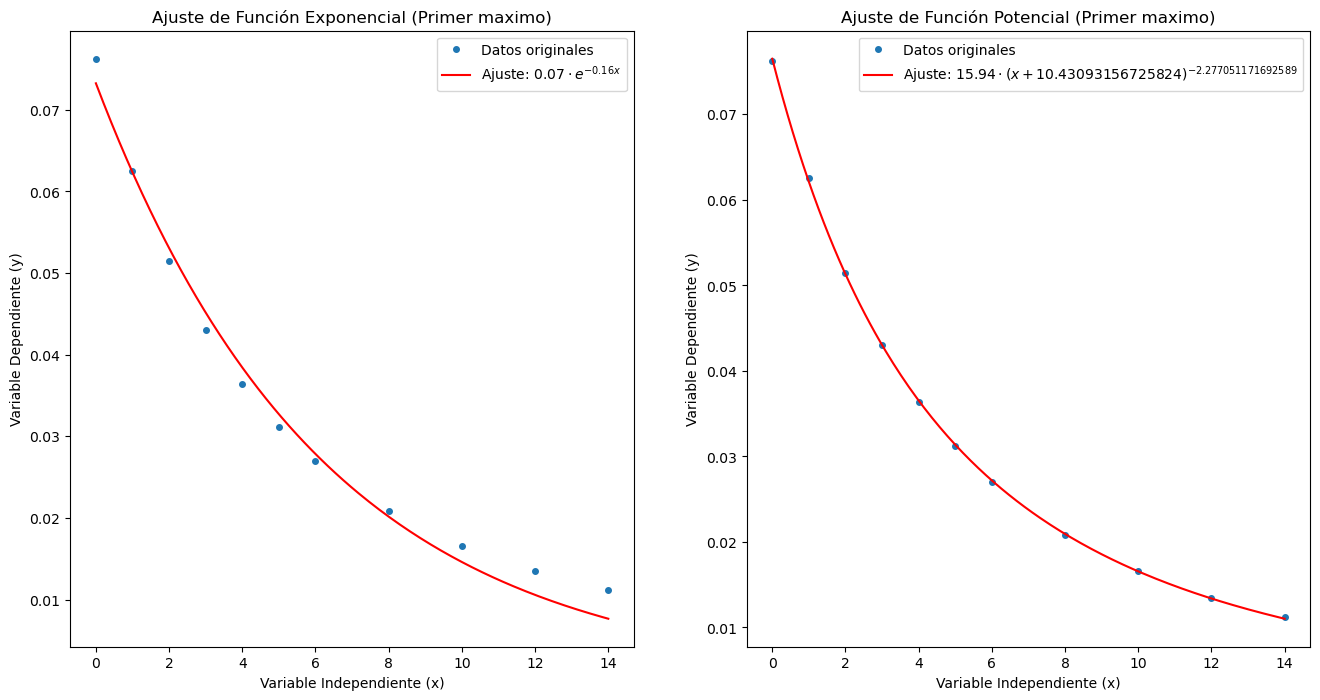

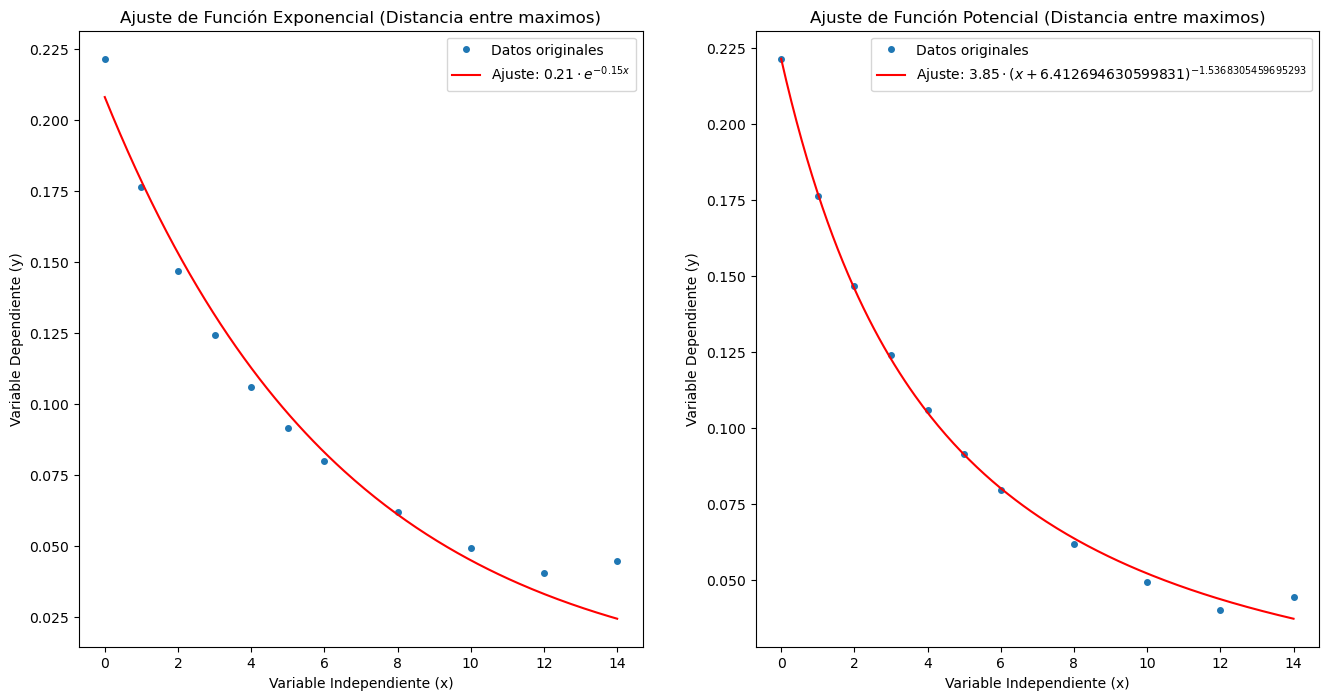

In [34]:
import scipy.optimize as opt

x = Data[:, 0]
y = Data[:, 1]


#DEFINO AQUÍ EL AJUSTE PARA UNA EXPONENCIAL
def exp_func(x, A, B):
    return A*np.exp(B*x)

#DEFINO AQUÍ EL AJUSTE PARA EL AJUSTE POTENCIAL
def pot_func(x, A, B, C):
    return A * np.power(x + C, B)

#Calculo el ajuste exponencial para el primer maximo
popt_exp, pcov_exp = opt.curve_fit(exp_func, x, y)

#Calculo los parámetros de ajuste de la potencia para el primer maximo
popt_pot, pcov_pot=opt.curve_fit(pot_func, x, y, p0=[0.1, -1, 1])


#MUESTRO TODOS LOS RESULTADOS DE LA EXPONENCIAL
print(f"Ajuste Exponencial: A = {popt_exp[0]:.4f}, B = {popt_exp[1]:.4f}")#el :.4f es una especificación de formato que dice a python que ponga 4 decimales como mucho y en notación no científica con la f

# 3. Visualización
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = exp_func(x_fit, *popt_exp)

fig, ax=plt.subplots(1, 2, figsize=(16,8))
ax[0].plot(x, y, 'o', label='Datos originales', markersize=4)
ax[0].plot(x_fit, y_fit, '-', label=f'Ajuste: ${popt_exp[0]:.2f} \cdot e^{{{popt_exp[1]:.2f}x}}$', color='red')

ax[0].set_xlabel('Variable Independiente (x)')
ax[0].set_ylabel('Variable Dependiente (y)')
ax[0].set_title('Ajuste de Función Exponencial (Primer maximo)')
ax[0].legend()


#MUESTRO TODOS LOS RESULTADOS DE LA POTENCIAL
print(f"Ajuste Exponencial: A = {popt_pot[0]:.4f}, B = {popt_pot[1]:.4f}")#el :.4f es una especificación de formato que dice a python que ponga 4 decimales como mucho y en notación no científica con la f

y_fit = pot_func(x_fit, *popt_pot)

ax[1].plot(x, y, 'o', label='Datos originales', markersize=4)
ax[1].plot(x_fit, y_fit, '-', label=f'Ajuste: ${popt_pot[0]:.2f} \cdot (x+{popt_pot[2]})^{{{popt_pot[1]}}}$', color='red')

ax[1].set_xlabel('Variable Independiente (x)')
ax[1].set_ylabel('Variable Dependiente (y)')
ax[1].set_title('Ajuste de Función Potencial (Primer maximo)')
ax[1].legend()


#Ya que estaba puse también el ajuste de las diferencias entre el primer y segundo máximo
y = Data[:, 2]
#Calculo el ajuste exponencial para el primer maximo
popt_exp, pcov_exp = opt.curve_fit(exp_func, x, y)

#Calculo los parámetros de ajuste de la potencia para el primer maximo
popt_pot, pcov_pot=opt.curve_fit(pot_func, x, y, p0=[0.1, -1, 1])

#MUESTRO TODOS LOS RESULTADOS DE LA EXPONENCIAL
print(f"Ajuste Exponencial: A = {popt_exp[0]:.4f}, B = {popt_exp[1]:.4f}")#el :.4f es una especificación de formato que dice a python que ponga 4 decimales como mucho y en notación no científica con la f

# 3. Visualización
x_fit = np.linspace(x.min(), x.max(), 200)
y_fit = exp_func(x_fit, *popt_exp)

fig, ax2=plt.subplots(1, 2, figsize=(16,8))
ax2[0].plot(x, y, 'o', label='Datos originales', markersize=4)
ax2[0].plot(x_fit, y_fit, '-', label=f'Ajuste: ${popt_exp[0]:.2f} \cdot e^{{{popt_exp[1]:.2f}x}}$', color='red')

ax2[0].set_xlabel('Variable Independiente (x)')
ax2[0].set_ylabel('Variable Dependiente (y)')
ax2[0].set_title('Ajuste de Función Exponencial (Distancia entre maximos)')
ax2[0].legend()


#MUESTRO TODOS LOS RESULTADOS DE LA POTENCIAL
print(f"Ajuste Exponencial: A = {popt_pot[0]:.4f}, B = {popt_pot[1]:.4f}")#el :.4f es una especificación de formato que dice a python que ponga 4 decimales como mucho y en notación no científica con la f

y_fit = pot_func(x_fit, *popt_pot)

ax2[1].plot(x, y, 'o', label='Datos originales', markersize=4)
ax2[1].plot(x_fit, y_fit, '-', label=f'Ajuste: ${popt_pot[0]:.2f} \cdot (x+{popt_pot[2]})^{{{popt_pot[1]}}}$', color='red')

ax2[1].set_xlabel('Variable Independiente (x)')
ax2[1].set_ylabel('Variable Dependiente (y)')
ax2[1].set_title('Ajuste de Función Potencial (Distancia entre maximos)')
ax2[1].legend()

plt.show()


# Me puse a ver cosas con el código de JR pero me da pereza usar JULIA lo siento

/var/folders/m5/912tdpsj605ckbd78snkwfqr0000gn/T/ipykernel_1266/984360258.py:38: RuntimeWarning: divide by zero encountered in divide
  - ((k1**2 + k2**2) / (2 * k1 * k2)) * np.sin(k1 * w) * np.sin(k2 * b)
/var/folders/m5/912tdpsj605ckbd78snkwfqr0000gn/T/ipykernel_1266/984360258.py:38: RuntimeWarning: invalid value encountered in divide
  - ((k1**2 + k2**2) / (2 * k1 * k2)) * np.sin(k1 * w) * np.sin(k2 * b)


<Figure size 1200x1000 with 0 Axes>

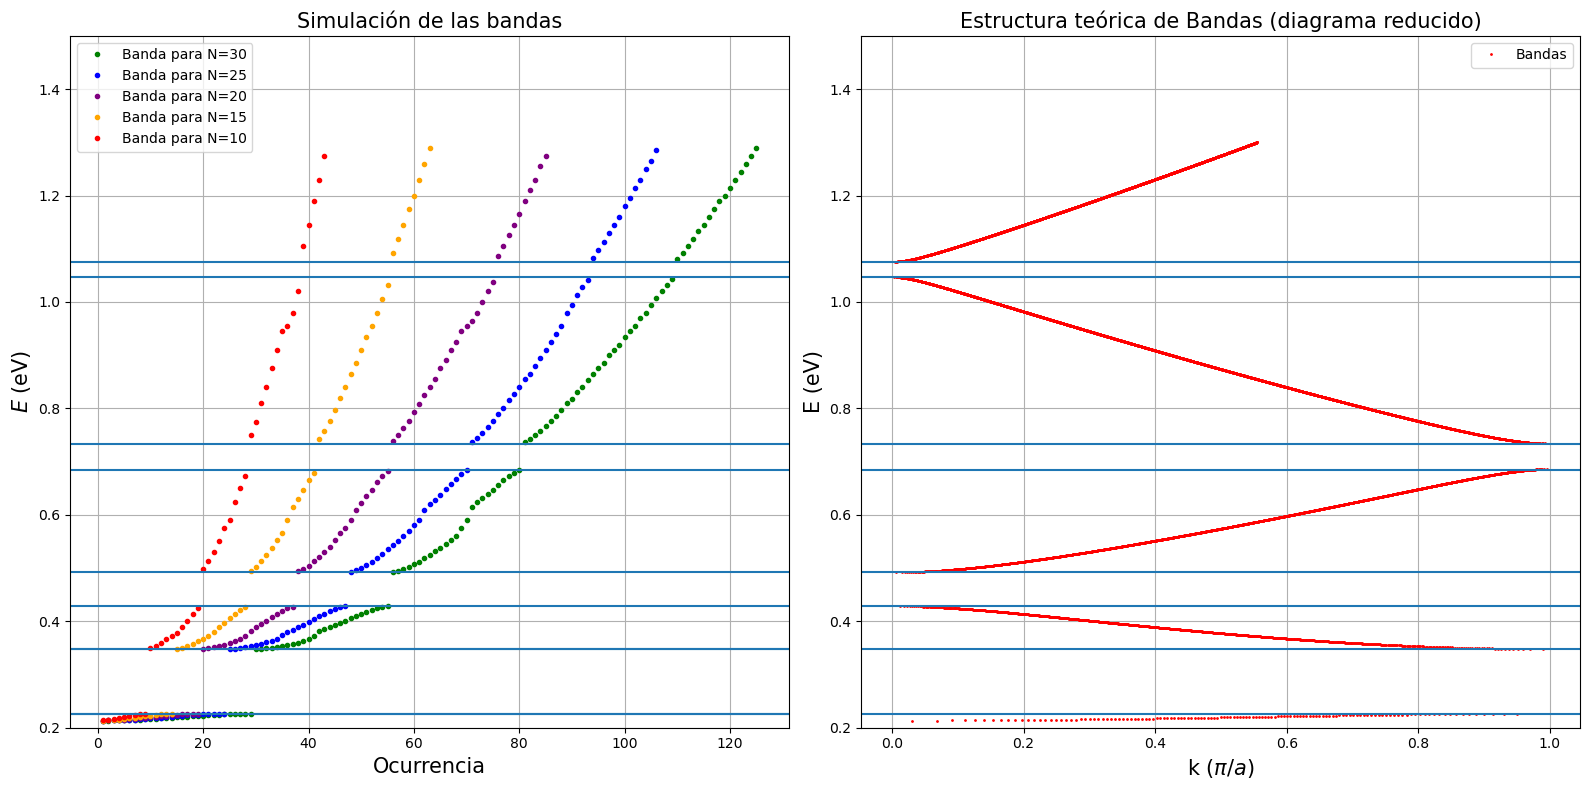

In [7]:
import matplotlib.pyplot as plt
import numpy as np


def Calcular_k(E, band, a, normalizar):
    Es = []
    ks = []

    for i in range(len(band)):
        # Condición para las zonas permitidas (bandas de energía)
        if abs(band[i]) <= 1.0:
            Es.append(E[i])
            if normalizar:
                ks.append(np.arccos(band[i]) / np.pi)  # En unidades de π/a
            else:
                ks.append(np.arccos(band[i]) / a)  # k en nm⁻¹

    return ks, Es


def Kronig_Penney(E, w, b, V0, m_eff=0.067, normalizado=False):
    a = w + b

    # Constantes físicas equivalentes en las unidades deseadas (eV y nm)
    # m_e * c^2 aprox 510998.95 eV
    # h_bar * c aprox 197.32697 eV*nm
    m_e_c2 = 510998.95
    hc_bar = 197.32697

    # En Python, para evitar problemas con raíces de números negativos,
    # convertimos el contenido a complejo usando dtype=complex o np.sqrt sobre complejos
    k1 = np.sqrt(2 * m_eff * m_e_c2 * E) / hc_bar
    k2 = np.sqrt(2 * m_eff * m_e_c2 * (E - V0 + 0j)) / hc_bar  # + 0j lo hace complejo

    # Cálculo de la función f (cos(ka))
    f = (
        np.cos(k1 * w) * np.cos(k2 * b)
        - ((k1**2 + k2**2) / (2 * k1 * k2)) * np.sin(k1 * w) * np.sin(k2 * b)
    )

    # Extraemos la parte real de la función (equivalente a real.(f))
    banda = np.real(f)

    # Obtenemos los vectores de k y E permitidos
    k_eff, E_eff = Calcular_k(E, banda, a, normalizado)

    return banda, k_eff, E_eff


# =============================================================================
# EJECUCIÓN PRINCIPAL
# =============================================================================

# Definición de parámetros
# np.arange(inicio, fin + paso, paso) para incluir el extremo final 1.0
Energy = np.arange(0, 1.3, 0.0001)
Barrier_Potential = 0.3
Barrier_width = 15.0
Well_width = 3.0

# Llamada a la función
banda, k_bandas, E_bandas = Kronig_Penney(
    Energy,
    Well_width,
    Barrier_width,
    Barrier_Potential,
    m_eff=0.023,
    normalizado=True,
)

# --- Gráfica 1: Energía vs Función de Banda ---
plt.figure(figsize=(12, 10))

#plt.subplot(1, 2, 1)  # Panel izquierdo
#plt.plot(Energy, banda, label=r"$f(E)$", color="blue")
#plt.axhline(y=1.0, color="red", linestyle="--", label="Límites de banda")
#plt.axhline(y=-1.0, color="red", linestyle="--")
#plt.xlabel("Energía (eV)")
#plt.ylabel("f(E)")
#plt.title("Zonas Permitidas y Prohibidas")
#plt.ylim(-2, 2)  # Acotamos el eje Y para ver mejor el cruce por 1 y -1
#plt.grid(True)
#plt.legend()

Data1 = np.genfromtxt("Simulador_Gap.txt", skip_header=3, delimiter=',', invalid_raise=False)
Data2 = np.genfromtxt("Bandas_Sim_N=5.txt", skip_header=3, delimiter=',', invalid_raise=False)
Data3 = np.genfromtxt("ocurrencia_Gap4_N=25.txt", skip_header=3, delimiter=',', invalid_raise=False)
Data4 = np.genfromtxt("ocurrencia_Gap4_N=15.txt", skip_header=3, delimiter=',', invalid_raise=False)
Data5 = np.genfromtxt("ocurrencia_Gap4_N=10.txt", skip_header=3, delimiter=',', invalid_raise=False)
Data6 = np.genfromtxt("ocurrencia_Gap4_N=20.txt", skip_header=3, delimiter=',', invalid_raise=False)
Data7 = np.genfromtxt("ocurrencia_Gap4_N=30.txt", skip_header=3, delimiter=',', invalid_raise=False)

x1=Data1[:, 0]
y1=Data1[:, 1]

x2=Data2[:, 0]
y2=Data2[:, 1]

x3=Data3[:, 0]
y3=Data3[:, 1]

x4=Data4[:, 0]
y4=Data4[:, 1]

x5=Data5[:, 0]
y5=Data5[:, 1]

x6=Data6[:, 0]
y6=Data6[:, 1]

x7=Data7[:, 0]
y7=Data7[:, 1]

fig, ax=plt.subplots(1,2, figsize=(16,8))

#ax[0].plot(x1,y1, '.', color='red', label="N=30")
ax[0].plot(x7,y7, '.', color='green', label="Banda para N=30")
ax[0].plot(x3,y3, '.', color='blue', label="Banda para N=25")
ax[0].plot(x6,y6, '.', color='purple', label="Banda para N=20")
ax[0].plot(x4,y4, '.', color='orange', label="Banda para N=15")
ax[0].plot(x5,y5, '.', color='red', label="Banda para N=10")

#ax[0].plot(x2,y2, '.', color='green', label="N=5")





ax[0].set_title("Simulación de las bandas", size=15)
ax[0].set_xlabel('Ocurrencia', size=15)
ax[0].set_ylabel(r'$E$ (eV)', size=15)
ax[0].set_ylim(0.2, 1.5)
ax[0].axhline(0.348073)
ax[0].axhline(0.226616)
ax[0].grid(True)

#PRIMER GAP
ax[0].axhline(0.2261)
ax[0].axhline(0.3476)
#SEGUNDO GAP
ax[0].axhline(0.4921)
ax[0].axhline(0.4278)
#TERCER GAP
ax[0].axhline(0.7335)
ax[0].axhline(0.6848)
#CUARTO GAP
ax[0].axhline(1.0758)
ax[0].axhline(1.0469)
ax[0].legend()




ax[1].plot(k_bandas, E_bandas, ".", color="red", markersize=2, label='Bandas')
#PRIMER GAP
ax[1].axhline(0.2261)
ax[1].axhline(0.3476)
#SEGUNDO GAP
ax[1].axhline(0.4921)
ax[1].axhline(0.4278)
#TERCER GAP
ax[1].axhline(0.7335)
ax[1].axhline(0.6848)
#CUARTO GAP
ax[1].axhline(1.0758)
ax[1].axhline(1.0469)


ax[1].set_xlabel(r"k ($\pi/a$)", size=15)
ax[1].set_ylabel("E (eV)", size=15)
ax[1].set_title("Estructura teórica de Bandas (diagrama reducido)", size=15)
ax[1].set_ylim(0.2, 1.5)
ax[1].grid(True)
ax[1].legend()





# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

Especifico que esto es para el primer gap entre bandas que sale. Para que el valor teórico tenga un límite de decimales diré que los gnomos pueden calcular hasta una cierta resolución de E=1e-4 eV con expresiones teóricas

# Quiero comprobar cómo la desviación relativa entre el gap primero simulado y el teorico baja a medida que aumento el número de barreras N

<>:51: SyntaxWarning: invalid escape sequence '\c'
<>:51: SyntaxWarning: invalid escape sequence '\c'
/var/folders/m5/912tdpsj605ckbd78snkwfqr0000gn/T/ipykernel_1266/249549532.py:51: SyntaxWarning: invalid escape sequence '\c'
  ax[1].plot(x_fit, y_fit, '-', label=f'Ajuste: ${popt_pot[0]:.2f} \cdot (x{popt_pot[2]:.2f})^{{{popt_pot[1]:.2f}}}$', color='red')
/var/folders/m5/912tdpsj605ckbd78snkwfqr0000gn/T/ipykernel_1266/249549532.py:26: RuntimeWarning: invalid value encountered in power
  return A * np.power(x + C, B)


Ajuste Exponencial: A = 0.2860, B = 4.2704
Coeficiente de determinación R²: 1.0000


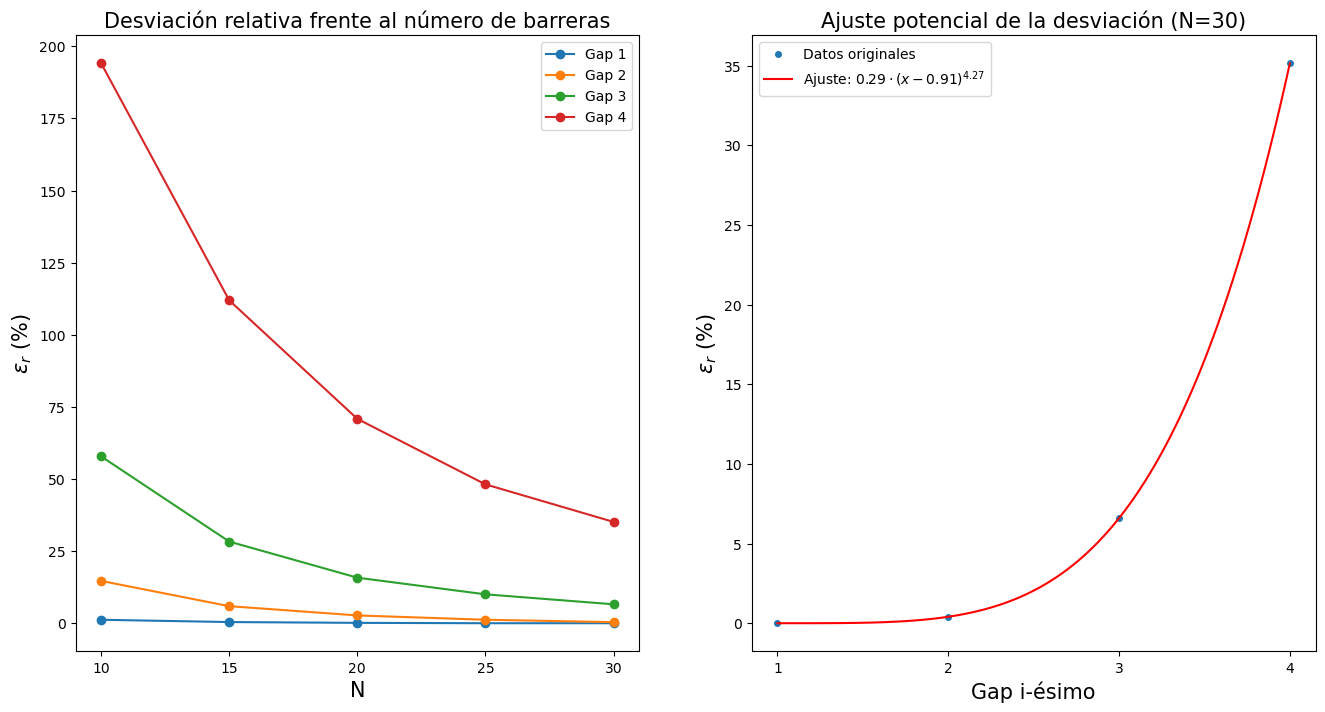

In [53]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from statistics import mean, stdev
import pandas as pd

Data=np.genfromtxt("Desv_relat_N.txt", skip_header=1, invalid_raise=False)

x=Data[:,0]

y1=Data[:,1]
y2=Data[:,2]
y3=Data[:,3]
y4=Data[:,4]

xajuste=np.array([1, 2, 3, 4])
yajuste=Data[4,1:]*100


x_fit = np.linspace(1, 4, 100)


#HAGO AJUSTES PARA N=30
#DEFINO AQUÍ EL AJUSTE PARA EL AJUSTE POTENCIAL
def pot_func(x, A, B, C):
    return A * np.power(x + C, B)

#Calculo los parámetros de ajuste de la potencia para el primer maximo
popt_pot, pcov_pot=opt.curve_fit(pot_func, xajuste, yajuste, p0=[0.0, 2.7, 2.0])

#MUESTRO TODOS LOS RESULTADOS DE LA POTENCIAL
print(f"Ajuste Exponencial: A = {popt_pot[0]:.4f}, B = {popt_pot[1]:.4f}")#el :.4f es una especificación de formato que dice a python que ponga 4 decimales como mucho y en notación no científica con la f


# CORRECCIÓN IMPORTANTE: Calcular y_fit (Faltaba en tu código)
y_fit = pot_func(x_fit, *popt_pot)

# --- CÁLCULO DEL R² (Para saber si la curva es buena) ---
y_predichos = pot_func(xajuste, *popt_pot) # Evalúa la curva en los puntos originales
residuo = yajuste - y_predichos
ss_res = np.sum(residuo**2)
ss_tot = np.sum((yajuste - np.mean(yajuste))**2)
r_cuadrado = 1 - (ss_res / ss_tot)

print(f'Coeficiente de determinación R²: {r_cuadrado:.4f}')


fig, ax=plt.subplots(1,2, figsize=(16, 8))

ax[1].plot(xajuste, yajuste, 'o', label='Datos originales', markersize=4)
ax[1].plot(x_fit, y_fit, '-', label=f'Ajuste: ${popt_pot[0]:.2f} \cdot (x{popt_pot[2]:.2f})^{{{popt_pot[1]:.2f}}}$', color='red')

ax[1].set_xlabel('Gap i-ésimo', size=15)
ax[1].set_ylabel(r'$\varepsilon_r$ (%)', size=15)
ax[1].set_title(r'Ajuste potencial de la desviación (N=30)', size=15)
ax[1].set_xticks(range(1, 4+1, 1))
ax[1].legend()


ax[0].plot(x,y1*100, marker="o" ,label="Gap 1")
ax[0].plot(x,y2*100, marker="o" ,label="Gap 2")
ax[0].plot(x,y3*100, marker="o" ,label="Gap 3")
ax[0].plot(x,y4*100, marker="o" ,label="Gap 4")


ax[0].set_xticks(range(10, 31, 5))


ax[0].set_ylabel(r'$\varepsilon_{r}$ (%)', size=15)
ax[0].set_xlabel("N", size=15)
ax[0].set_title("Desviación relativa frente al número de barreras", size=15)
ax[0].legend()

plt.show()
